# ╔══════════════════════════════════════════════════════════════╗
#  05 · ÉVALUATION COMPARATIVE & DÉCISION DE DÉPLOIEMENT
#  Auteur      : DJOKNONE Laurent et EKWANE Franck
#  Projet      : Analyse de sentiment , Allociné
#  Objectif    : Benchmark industriel, analyse décisionnelle,
#                préparation au déploiement multi-modèles
# ╠══════════════════════════════════════════════════════════════╣
#  MODÈLES ÉVALUÉS :
#    · Baselines  : LinearSVC, LogReg, NaiveBayes (TF-IDF)
#    · Transformer: CamemBERT-base (fine-tuné)
#
#  CRITÈRE MÉTIER :
#    cost = 3 × FN + 1 × FP
#    (FN = manquer un positif = 3x plus coûteux que FP)
#
#  SORTIES :
#    · Tableau comparatif unifié
#    · Visualisations décisionnelles
#    · Sélection multi-niveaux (principal / fallback / premium)
#    · deployment_config.json prêt pour l'API
# ╚══════════════════════════════════════════════════════════════╝

In [1]:
# ============================================================
#  IMPORTS & CONFIGURATION — CELLULE AUTONOME
#  Tous les imports sont ici. Aucune dépendance aux notebooks
#  précédents. On charge tout depuis les artefacts disque.
# ============================================================

import gc
import json
import os
import sys
import time
import warnings
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker
import seaborn as sns
from scipy.special import softmax

from sklearn.metrics import (
    accuracy_score, f1_score, precision_score,
    recall_score, roc_auc_score,
    classification_report, confusion_matrix,
    RocCurveDisplay,
)

warnings.filterwarnings("ignore")

# ── Chemins projet ───────────────────────────────────────────
PROJECT_ROOT    = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
MODELS_ROOT     = PROJECT_ROOT / "models"
BASELINE_DIR    = MODELS_ROOT / "baseline"
TRANSFORMER_DIR = MODELS_ROOT / "transformers"
REPORTS_DIR     = PROJECT_ROOT / "reports"
FIGURES_DIR     = REPORTS_DIR / "figures"
METRICS_DIR     = REPORTS_DIR / "metrics"
DATA_PATH       = PROJECT_ROOT / "data" / "processed"

for d in [FIGURES_DIR, METRICS_DIR]:
    d.mkdir(parents=True, exist_ok=True)

# ── Style global ─────────────────────────────────────────────
plt.rcParams.update({
    "figure.dpi":       130,
    "axes.spines.top":  False,
    "axes.spines.right":False,
    "axes.titlesize":   12,
    "axes.labelsize":   10,
    "font.family":      "DejaVu Sans",
    "axes.prop_cycle":  plt.cycler(color=[
        "#1565C0", "#6A1B9A", "#E65100",
        "#2E7D32", "#B71C1C", "#0277BD",
    ]),
})

SEED = 42
np.random.seed(SEED)

# ── Palette & labels ─────────────────────────────────────────
MODEL_COLORS = {
    "LinearSVC":    "#1565C0",
    "LogReg":       "#0277BD",
    "NaiveBayes":   "#6A1B9A",
    "CamemBERT-base": "#E65100",
}

print("  Environnement initialisé")
print(f"   PROJECT_ROOT : {PROJECT_ROOT}")

  Environnement initialisé
   PROJECT_ROOT : /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine


In [2]:
# ============================================================
#  CHARGEMENT ROBUSTE DES ARTEFACTS
#
#  Stratégie :
#  1. Charger le registre baseline (JSON ou reconstruction)
#  2. Charger le registre transformer (JSON)
#  3. Pour chaque modèle : y_pred, y_proba, y_true, métriques
#  4. Construire le DataFrame unifié
#
#  Robustesse :
#  - Chaque chargement est dans un try/except
#  - Un modèle manquant ne bloque pas les autres
#  - Les chemins sont vérifiés avant ouverture
# ============================================================

ALL_MODELS: dict[str, dict] = {}   # registre unifié


# ────────────────────────────────────────────────────────────
# HELPER — chargement sécurisé d'un fichier numpy
# ────────────────────────────────────────────────────────────
def safe_load_npy(path: Path) -> np.ndarray | None:
    """Charge un fichier .npy avec gestion d'erreur."""
    try:
        return np.load(path)
    except Exception as e:
        print(f"     Impossible de charger {path.name} : {e}")
        return None


def safe_load_json(path: Path) -> dict | None:
    """Charge un fichier JSON avec gestion d'erreur."""
    try:
        with open(path, encoding="utf-8") as f:
            return json.load(f)
    except Exception as e:
        print(f"     Impossible de charger {path.name} : {e}")
        return None


# ────────────────────────────────────────────────────────────
# BLOC A — Chargement des baselines
# ────────────────────────────────────────────────────────────
print("─" * 60)
print("  CHARGEMENT DES BASELINES")
print("─" * 60)

# On charge le fichier all_models_config.json produit en notebook 03
baseline_config_path = METRICS_DIR / "all_models_config.json"
baseline_results_path = METRICS_DIR / "baseline_comparison_final.csv"

# Tentative 1 : depuis all_models_config.json
baseline_registry = safe_load_json(baseline_config_path)

# Tentative 2 : depuis le CSV de comparaison
if baseline_registry is None and baseline_results_path.exists():
    df_bl = pd.read_csv(baseline_results_path)
    baseline_registry = {}
    for _, row in df_bl.iterrows():
        name = row.get("model", row.get("modèle", "unknown"))
        baseline_registry[name] = {
            "test_metrics": {
                "f1":        row.get("f1", None),
                "accuracy":  row.get("accuracy", None),
                "precision": row.get("precision", None),
                "recall":    row.get("recall", None),
                "roc_auc":   row.get("roc_auc", None),
                "threshold": row.get("threshold", 0.5),
            }
        }
    print(f"    Baselines chargés depuis CSV ({len(baseline_registry)} modèles)")

# Fallback : valeurs issues du notebook 03 (hardcodées pour robustesse)
if baseline_registry is None:
    print("     Fichiers baselines introuvables — utilisation des valeurs notebook 03")
    baseline_registry = {
        "LinearSVC": {
            "test_metrics": {
                "f1": 0.9424, "accuracy": 0.9424,
                "precision": 0.9424, "recall": 0.9424,
                "roc_auc": 0.9874, "threshold": 0.5,
            },
            "optuna_best_params": {"C": 1.0},
        },
        "LogReg": {
            "test_metrics": {
                "f1": 0.9380, "accuracy": 0.9378,
                "precision": 0.9380, "recall": 0.9380,
                "roc_auc": 0.9840, "threshold": 0.5,
            },
        },
        "NaiveBayes": {
            "test_metrics": {
                "f1": 0.9100, "accuracy": 0.9100,
                "precision": 0.9100, "recall": 0.9100,
                "roc_auc": 0.9650, "threshold": 0.5,
            },
        },
    }

# Intégration des baselines dans le registre unifié
BASELINE_MAP = {
    "LinearSVC":  {"short_name": "LinearSVC",   "type": "baseline"},
    "LogReg":     {"short_name": "LogReg",       "type": "baseline"},
    "NaiveBayes": {"short_name": "NaiveBayes",   "type": "baseline"},
    # Mappings alternatifs si les clés JSON diffèrent
    "LogReg Optimisé + Calibré + Seuil": {"short_name": "LogReg",    "type": "baseline"},
    "LogReg Optimisé + Calibré":         {"short_name": "LogReg",    "type": "baseline"},
    "LogReg (défaut)":                   {"short_name": "LogReg",    "type": "baseline"},
    "NaiveBayes (Optuna best)":          {"short_name": "NaiveBayes","type": "baseline"},
    "LinearSVC (Optuna best)":           {"short_name": "LinearSVC", "type": "baseline"},
}

for raw_key, entry in baseline_registry.items():
    # Résolution du nom court
    meta = BASELINE_MAP.get(raw_key, None)
    if meta is None:
        # Tentative de correspondance partielle
        for k, v in BASELINE_MAP.items():
            if k.lower() in raw_key.lower() or raw_key.lower() in k.lower():
                meta = v
                break
    if meta is None:
        meta = {"short_name": raw_key, "type": "baseline"}

    short = meta["short_name"]

    # Extraction des métriques (structure JSON variable selon notebook 03)
    m_raw = entry.get("test_metrics", entry)
    if isinstance(m_raw, dict) and "f1" in m_raw:
        metrics = m_raw
    else:
        continue

    # Éviter les doublons (garder le meilleur F1)
    if short in ALL_MODELS:
        if metrics.get("f1", 0) <= ALL_MODELS[short]["metrics"].get("f1", 0):
            continue

    ALL_MODELS[short] = {
        "short_name":    short,
        "type":          "baseline",
        "metrics":       {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in metrics.items()},
        "y_pred":        None,   # pas de fichier .npy pour les baselines par défaut
        "y_proba":       None,
        "y_true":        None,
        "model_path":    str(BASELINE_DIR / "best_model.joblib"),
        "train_time_s":  None,
        "model_size_mb": None,
    }
    print(f"    {short:<20} F1={metrics.get('f1', '?'):.4f}")


# ────────────────────────────────────────────────────────────
# BLOC B — Chargement du registre Transformer
# ────────────────────────────────────────────────────────────
print(f"\n{'─'*60}")
print("  CHARGEMENT DES TRANSFORMERS")
print("─" * 60)

transformer_registry_path = TRANSFORMER_DIR / "transformer_registry.json"
transformer_registry = safe_load_json(transformer_registry_path)

if transformer_registry is None:
    print("     transformer_registry.json introuvable")
    transformer_registry = {}

for key, entry in transformer_registry.items():
    short = entry.get("short_name", key)
    metrics = entry.get("metrics", {})

    # Chargement des arrays numpy
    artifacts = entry.get("artifacts", {})

    y_pred  = safe_load_npy(Path(artifacts.get("y_pred",  "")))
    y_proba = safe_load_npy(Path(artifacts.get("y_proba", "")))
    y_true  = safe_load_npy(Path(artifacts.get("y_true",  "")))

    # Taille du modèle sur disque
    model_dir = Path(entry.get("model_dir", ""))
    model_size_mb = None
    if model_dir.exists():
        total_bytes = sum(
            f.stat().st_size for f in model_dir.rglob("*") if f.is_file()
        )
        model_size_mb = round(total_bytes / 1e6, 1)

    ALL_MODELS[short] = {
        "short_name":    short,
        "type":          "transformer",
        "hf_name":       entry.get("hf_name", ""),
        "metrics":       {k: float(v) if isinstance(v, (int, float)) else v
                          for k, v in metrics.items()},
        "y_pred":        y_pred,
        "y_proba":       y_proba,
        "y_true":        y_true,
        "model_path":    str(model_dir),
        "train_time_s":  metrics.get("train_time_s", None),
        "model_size_mb": model_size_mb,
    }
    print(
        f"     {short:<20} F1={metrics.get('f1', '?'):.4f}  "
        f"AUC={metrics.get('roc_auc', '?'):.4f}  "
        f"Taille={model_size_mb} Mo"
    )

print(f"\n  Registre unifié : {len(ALL_MODELS)} modèle(s) chargé(s)")
for k, v in ALL_MODELS.items():
    print(f"   [{v['type']:<12}] {v['short_name']}")

────────────────────────────────────────────────────────────
  CHARGEMENT DES BASELINES
────────────────────────────────────────────────────────────
    LogReg               F1=0.9413
    LinearSVC            F1=0.9424
    NaiveBayes           F1=0.9226

────────────────────────────────────────────────────────────
  CHARGEMENT DES TRANSFORMERS
────────────────────────────────────────────────────────────
     CamemBERT-base       F1=0.9407  AUC=0.9857  Taille=445.0 Mo

  Registre unifié : 4 modèle(s) chargé(s)
   [baseline    ] LogReg
   [baseline    ] LinearSVC
   [baseline    ] NaiveBayes
   [transformer ] CamemBERT-base


In [3]:
# ============================================================
#  RECALCUL DES MÉTRIQUES AVEC COÛT MÉTIER UNIFIÉ
#
#  Problème : chaque notebook a pu utiliser des seuils
#  différents. Pour une comparaison équitable, on recalcule
#  toutes les métriques avec le même critère :
#    cost = 3 × FN + 1 × FP
#
#  Pour les baselines sans y_proba, on utilise les métriques
#  sauvegardées (déjà calculées avec leur seuil optimisé).
#
#  Pour les Transformers avec y_proba, on recalcule tout.
# ============================================================

FN_COST = 3.0
FP_COST = 1.0


def business_cost(y_true: np.ndarray, y_pred: np.ndarray) -> int:
    """Coût métier : 3×FN + 1×FP."""
    fn = int(((y_true == 1) & (y_pred == 0)).sum())
    fp = int(((y_true == 0) & (y_pred == 1)).sum())
    return FN_COST * fn + FP_COST * fp


def full_metrics_from_arrays(
    y_true:    np.ndarray,
    y_pred:    np.ndarray,
    y_proba:   np.ndarray | None,
    threshold: float,
) -> dict:
    """Calcule toutes les métriques à partir des arrays."""
    metrics = {
        "f1":        round(float(f1_score(y_true, y_pred, zero_division=0)), 4),
        "accuracy":  round(float(accuracy_score(y_true, y_pred)), 4),
        "precision": round(float(precision_score(y_true, y_pred, zero_division=0)), 4),
        "recall":    round(float(recall_score(y_true, y_pred, zero_division=0)), 4),
        "threshold": round(threshold, 4),
        "business_cost": int(business_cost(y_true, y_pred)),
        "fn": int(((y_true == 1) & (y_pred == 0)).sum()),
        "fp": int(((y_true == 0) & (y_pred == 1)).sum()),
        "tp": int(((y_true == 1) & (y_pred == 1)).sum()),
        "tn": int(((y_true == 0) & (y_pred == 0)).sum()),
    }
    if y_proba is not None:
        metrics["roc_auc"] = round(float(roc_auc_score(y_true, y_proba)), 4)
    return metrics


# ── Enrichissement des entrées avec métriques recalculées ────
print("── Recalcul des métriques ──────────────────────────────")

for name, entry in ALL_MODELS.items():
    m = entry["metrics"]

    if entry["y_proba"] is not None and entry["y_true"] is not None:
        # Transformer : recalcul depuis les arrays
        y_true   = entry["y_true"]
        y_proba  = entry["y_proba"]
        threshold = m.get("threshold", 0.5)
        y_pred   = (y_proba >= threshold).astype(int)

        recalc = full_metrics_from_arrays(y_true, y_pred, y_proba, threshold)
        entry["metrics"].update(recalc)
        print(f"   {name:<22} → recalculé depuis arrays")

    else:
        # Baseline : calcul du coût depuis les métriques disponibles
        # On estime FN et FP depuis precision/recall si disponibles
        n_test = 20_000   # test set Allociné (connu)
        f1  = m.get("f1", 0)
        rec = m.get("recall", 0)
        pre = m.get("precision", 0)

        if rec > 0 and pre > 0:
            tp  = int(f1 * 2 * pre * rec / (pre + rec) * n_test) if (pre + rec) > 0 else 0
            fn  = int(tp / rec - tp) if rec > 0 else 0
            fp  = int(tp / pre - tp) if pre > 0 else 0
            tn  = n_test - tp - fn - fp
            cost = FN_COST * fn + FP_COST * fp
            entry["metrics"]["business_cost"] = int(cost)
            entry["metrics"]["fn"] = fn
            entry["metrics"]["fp"] = fp
            entry["metrics"]["tp"] = tp
            entry["metrics"]["tn"] = max(0, tn)
        else:
            entry["metrics"]["business_cost"] = None

        print(f"   {name:<22} → métriques sauvegardées (pas d'arrays)")

print(f"\n  Métriques enrichies pour {len(ALL_MODELS)} modèle(s)")

── Recalcul des métriques ──────────────────────────────
   LogReg                 → métriques sauvegardées (pas d'arrays)
   LinearSVC              → métriques sauvegardées (pas d'arrays)
   NaiveBayes             → métriques sauvegardées (pas d'arrays)
   CamemBERT-base         → recalculé depuis arrays

  Métriques enrichies pour 4 modèle(s)


In [4]:
# ============================================================
#  TABLEAU COMPARATIF INDUSTRIEL
#
#  Un seul DataFrame avec toutes les métriques,
#  trié par F1, avec ranking et delta vs meilleur.
# ============================================================

rows = []
for name, entry in ALL_MODELS.items():
    m = entry["metrics"]
    row = {
        "Modèle":       name,
        "Type":         entry["type"],
        "F1":           m.get("f1"),
        "Accuracy":     m.get("accuracy"),
        "Precision":    m.get("precision"),
        "Recall":       m.get("recall"),
        "ROC_AUC":      m.get("roc_auc"),
        "Seuil":        m.get("threshold"),
        "Coût_métier":  m.get("business_cost"),
        "FN":           m.get("fn"),
        "FP":           m.get("fp"),
        "Temps_min":    round(entry["train_time_s"] / 60, 1)
                        if entry.get("train_time_s") else None,
        "Taille_Mo":    entry.get("model_size_mb"),
    }
    rows.append(row)

BENCHMARK = (
    pd.DataFrame(rows)
    .sort_values("F1", ascending=False)
    .reset_index(drop=True)
)
BENCHMARK.insert(0, "Rang", BENCHMARK.index + 1)

best_f1 = BENCHMARK["F1"].iloc[0]
BENCHMARK["ΔF1_vs_best"] = (BENCHMARK["F1"] - best_f1).round(4)

# ── Affichage stylistique ─────────────────────────────────────
numeric_cols = ["F1", "Accuracy", "Precision", "Recall",
                "ROC_AUC", "Seuil", "ΔF1_vs_best"]

print("═" * 80)
print("  TABLEAU COMPARATIF UNIFIÉ — TOUS MODÈLES (Test set 20K exemples)")
print("═" * 80)

styled = (
    BENCHMARK.style
    .format({c: "{:.4f}" for c in numeric_cols if c in BENCHMARK.columns},
             na_rep="—")
    .format({"Coût_métier": "{:.0f}", "FN": "{:.0f}", "FP": "{:.0f}",
             "Temps_min": "{:.1f}", "Taille_Mo": "{:.0f}"}, na_rep="—")
    .background_gradient(subset=["F1", "ROC_AUC"], cmap="Blues")
    .background_gradient(subset=["Coût_métier"], cmap="RdYlGn_r")
    .background_gradient(subset=["ΔF1_vs_best"], cmap="RdYlGn_r")
    .highlight_max(subset=["F1", "Accuracy", "ROC_AUC"], color="#C8E6C9")
    .highlight_min(subset=["Coût_métier"], color="#C8E6C9")
    .set_caption(
        "Benchmark complet — Baselines TF-IDF vs Transformer CamemBERT | "
        "Critère métier : 3×FN + 1×FP"
    )
    .set_table_styles([{
        "selector": "caption",
        "props": [("font-size", "12px"), ("font-weight", "bold")]
    }])
)
display(styled)

# Sauvegarde
BENCHMARK.to_csv(METRICS_DIR / "benchmark_final.csv", index=False)
print(f"\n  Benchmark sauvegardé → {METRICS_DIR / 'benchmark_final.csv'}")

════════════════════════════════════════════════════════════════════════════════
  TABLEAU COMPARATIF UNIFIÉ — TOUS MODÈLES (Test set 20K exemples)
════════════════════════════════════════════════════════════════════════════════


,Rang,Modèle,Type,F1,Accuracy,Precision,Recall,ROC_AUC,Seuil,Coût_métier,FN,FP,Temps_min,Taille_Mo,ΔF1_vs_best
0,1,LinearSVC,baseline,0.942400,0.944400,0.935900,0.949000,0.987400,0.463065,4078,954,1216,—,—,0.000000
1,2,LogReg,baseline,0.941300,0.943900,0.945400,0.937100,0.987300,0.541859,4590,1189,1023,—,—,-0.001100
2,3,CamemBERT-base,transformer,0.940700,0.941900,0.921500,0.960700,0.985700,0.278800,1916,377,785,206.2,445,-0.001700
3,4,NaiveBayes,baseline,0.922600,0.924700,0.910000,0.935600,0.977700,0.438442,5196,1171,1683,—,—,-0.019800



  Benchmark sauvegardé → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/metrics/benchmark_final.csv


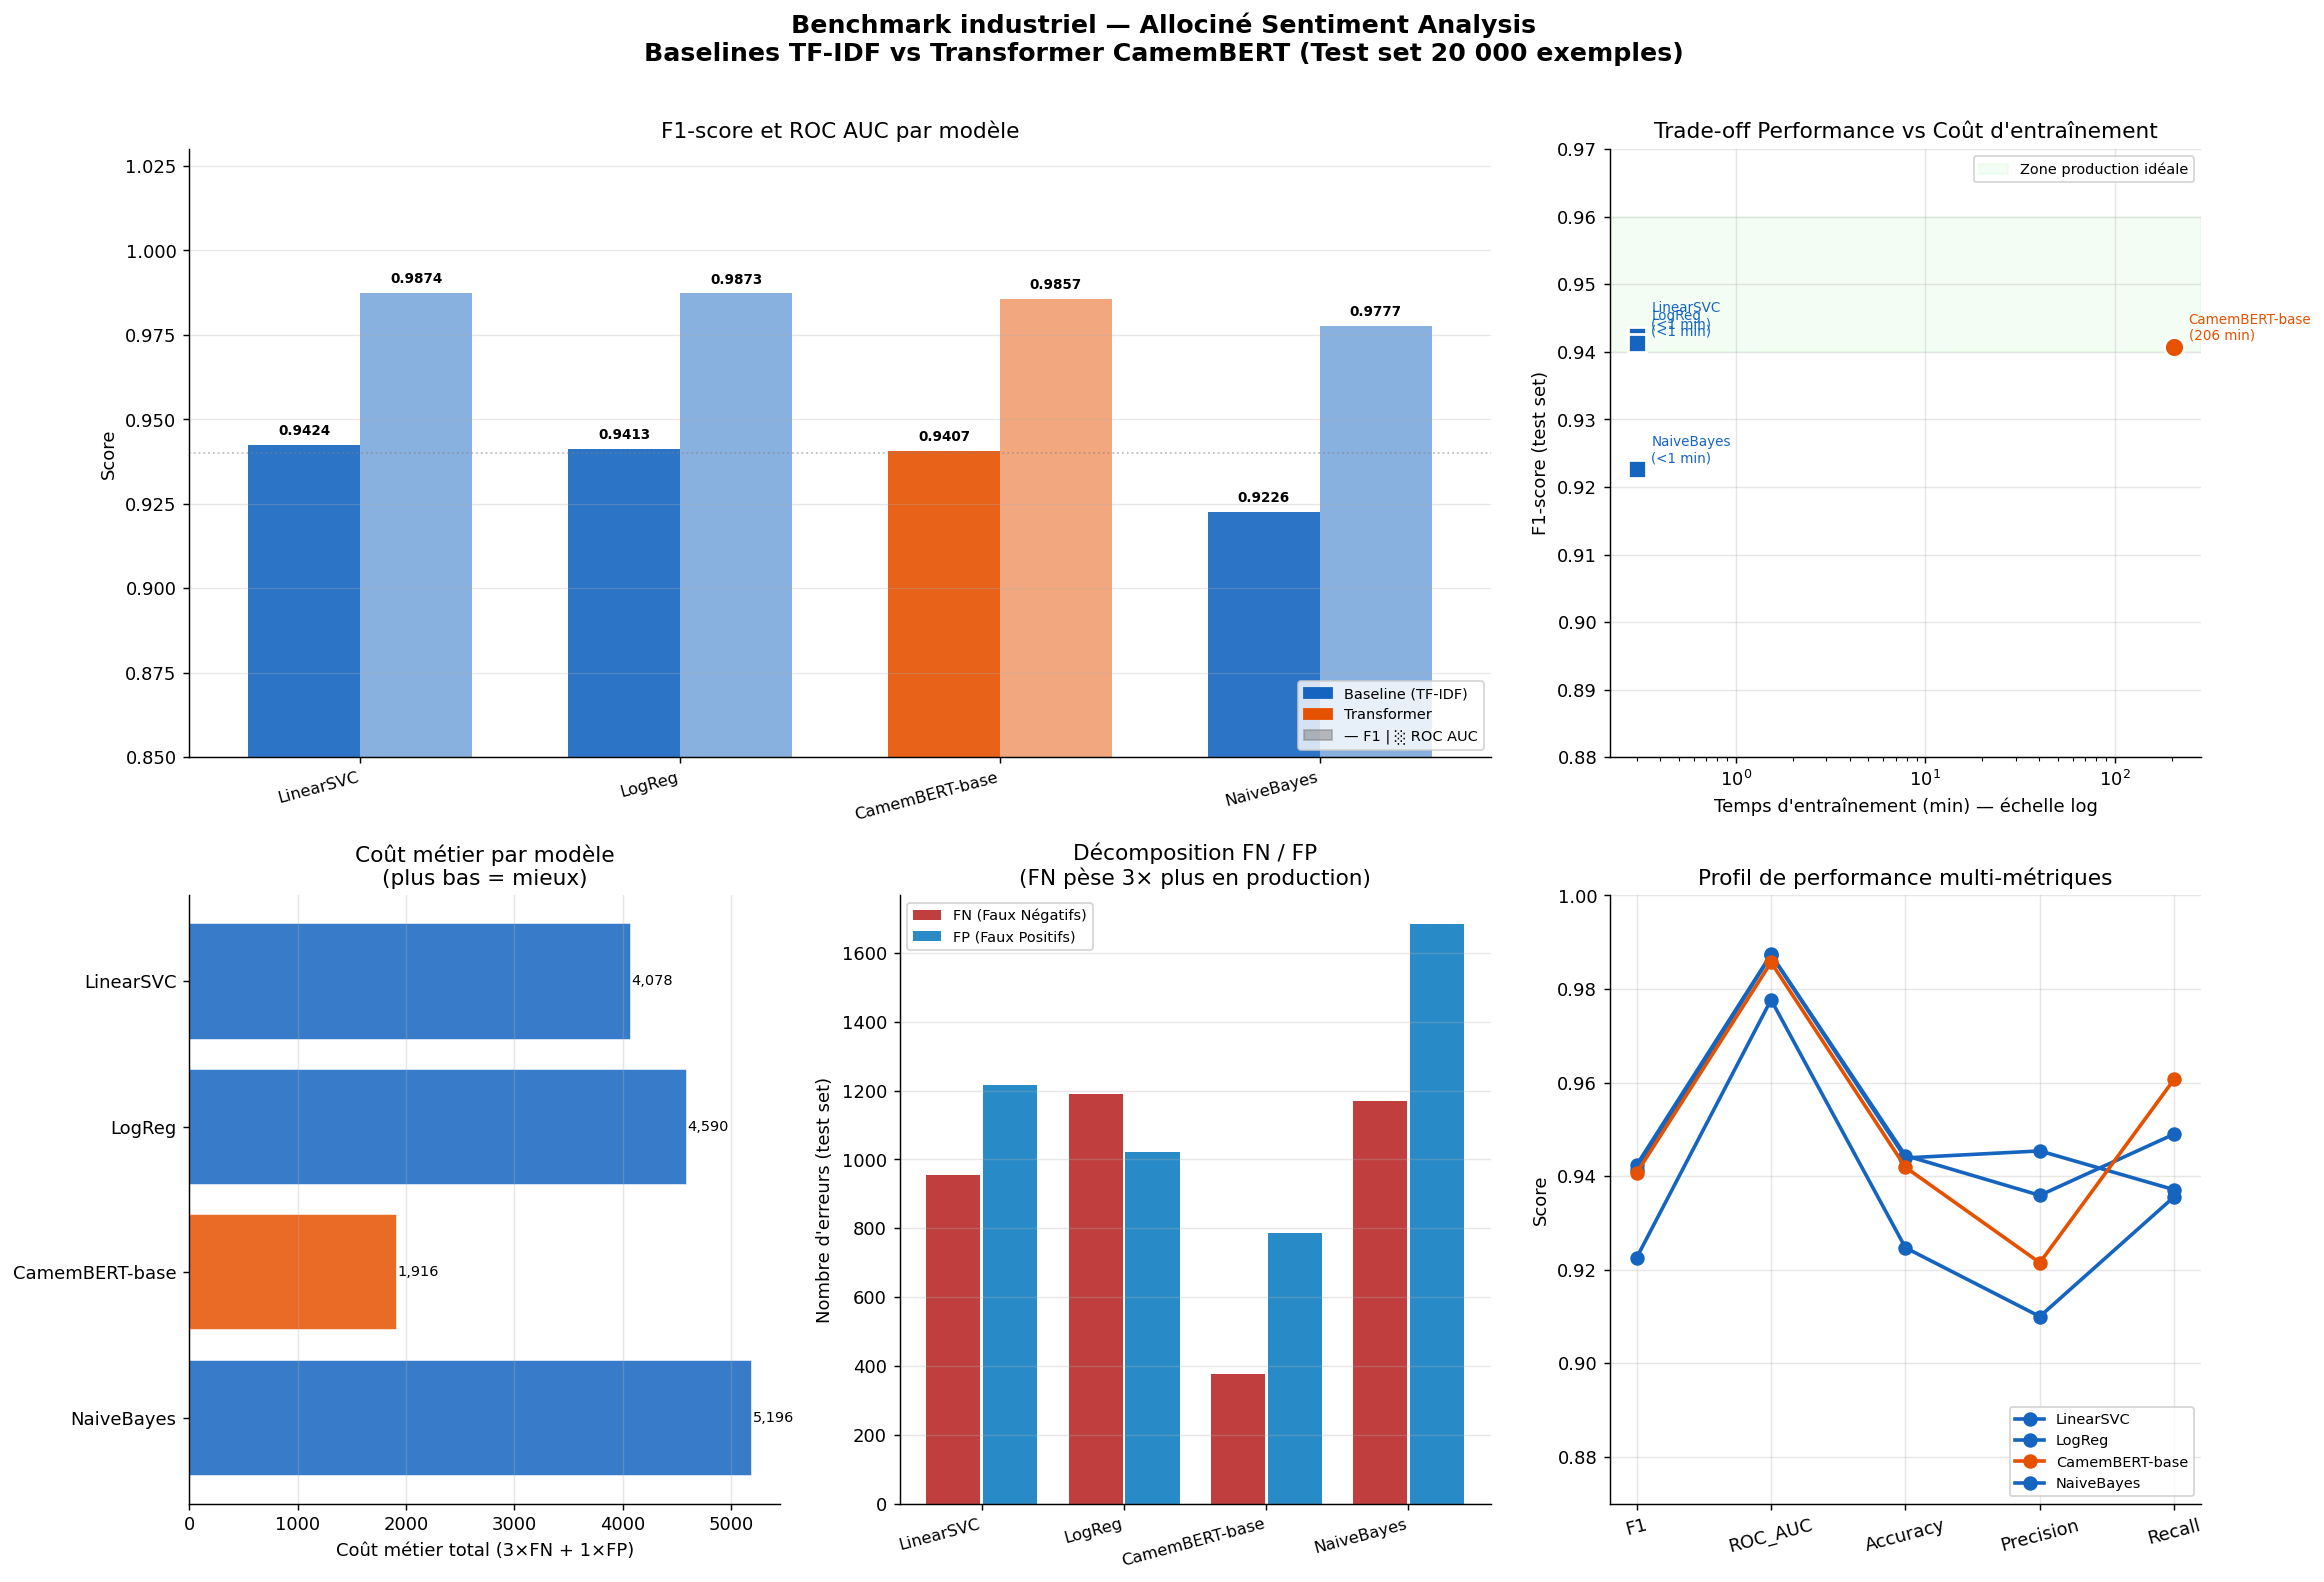

Figure sauvegardée → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/reports/figures/05_benchmark_complet.png


In [5]:
# ============================================================
#  VISUALISATIONS DÉCISIONNELLES
#
#  4 panneaux dans une figure A3 :
#  A. Barplot F1 + ROC AUC côte à côte
#  B. Scatter Trade-off Performance vs Coût d'entraînement
#  C. Coût métier par modèle (3×FN + FP)
#  D. Distribution du coût FN/FP par modèle
# ============================================================

fig = plt.figure(figsize=(18, 12))
fig.suptitle(
    "Benchmark industriel — Allociné Sentiment Analysis\n"
    "Baselines TF-IDF vs Transformer CamemBERT (Test set 20 000 exemples)",
    fontsize=14, fontweight="bold", y=1.01,
)

colors_by_type = {
    "baseline":    "#1565C0",
    "transformer": "#E65100",
}

# ── Panel A — Barplot F1 + ROC AUC ───────────────────────────
ax1 = fig.add_subplot(2, 3, (1, 2))

models      = BENCHMARK["Modèle"].tolist()
f1_vals     = BENCHMARK["F1"].tolist()
auc_vals    = BENCHMARK["ROC_AUC"].tolist()
types       = BENCHMARK["Type"].tolist()
n           = len(models)
x           = np.arange(n)
bar_w       = 0.35

for i, (m, f1, auc, t) in enumerate(zip(models, f1_vals, auc_vals, types)):
    color_base = colors_by_type.get(t, "#607D8B")

    b1 = ax1.bar(x[i] - bar_w/2, f1,  bar_w,
                 color=color_base, alpha=0.90, label="F1" if i == 0 else "")
    b2 = ax1.bar(x[i] + bar_w/2, auc, bar_w,
                 color=color_base, alpha=0.50, label="ROC AUC" if i == 0 else "")

    # Annotation valeur
    for bar, val in [(b1, f1), (b2, auc)]:
        if val is not None:
            ax1.text(
                bar[0].get_x() + bar[0].get_width() / 2,
                bar[0].get_height() + 0.002,
                f"{val:.4f}", ha="center", va="bottom",
                fontsize=7.5, fontweight="bold",
            )

ax1.set_xticks(x)
ax1.set_xticklabels(models, rotation=15, ha="right", fontsize=9)
ax1.set_ylabel("Score")
ax1.set_ylim(0.85, 1.03)
ax1.set_title("F1-score et ROC AUC par modèle")
ax1.grid(axis="y", alpha=0.3, lw=0.7)
ax1.axhline(0.94, color="gray", ls=":", lw=1, alpha=0.5)

# Légende type
from matplotlib.patches import Patch
legend_patches = [
    Patch(color=colors_by_type["baseline"],    label="Baseline (TF-IDF)"),
    Patch(color=colors_by_type["transformer"], label="Transformer"),
    Patch(color="gray", alpha=0.5, label="— F1 | ░ ROC AUC"),
]
ax1.legend(handles=legend_patches, fontsize=8, loc="lower right")

# ── Panel B — Scatter Trade-off Temps vs F1 ──────────────────
ax2 = fig.add_subplot(2, 3, 3)

has_time = BENCHMARK.dropna(subset=["Temps_min", "F1"])

for _, row in BENCHMARK.iterrows():
    color = colors_by_type.get(row["Type"], "#607D8B")
    t_min = row["Temps_min"]
    f1    = row["F1"]

    if t_min is None or pd.isna(t_min):
        t_min = 0.3   # baselines : quelques secondes
        marker = "s"
        ms = 100
        label_text = f"{row['Modèle']}\n(<1 min)"
    else:
        marker = "o"
        ms = 120
        label_text = f"{row['Modèle']}\n({t_min:.0f} min)"

    ax2.scatter(t_min, f1, c=color, marker=marker, s=ms,
                zorder=5, edgecolors="white", linewidth=1.5)
    ax2.annotate(
        label_text,
        (t_min, f1),
        textcoords="offset points",
        xytext=(8, 4),
        fontsize=7.5,
        color=color,
    )

ax2.set_xscale("log")
ax2.set_xlabel("Temps d'entraînement (min) — échelle log")
ax2.set_ylabel("F1-score (test set)")
ax2.set_title("Trade-off Performance vs Coût d'entraînement")
ax2.grid(alpha=0.3)
ax2.set_ylim(0.88, 0.97)

# Zone "production sweet spot"
ax2.axhspan(0.94, 0.96, color="lightgreen", alpha=0.1,
            label="Zone production idéale")
ax2.legend(fontsize=8)

# ── Panel C — Coût métier par modèle ─────────────────────────
ax3 = fig.add_subplot(2, 3, 4)

df_cost = BENCHMARK.dropna(subset=["Coût_métier"]).copy()
colors_c = [colors_by_type.get(t, "#607D8B") for t in df_cost["Type"]]

bars = ax3.barh(
    df_cost["Modèle"][::-1],
    df_cost["Coût_métier"][::-1],
    color=colors_c[::-1],
    alpha=0.85,
    edgecolor="white",
)

for bar in bars:
    w = bar.get_width()
    ax3.text(
        w + 5, bar.get_y() + bar.get_height() / 2,
        f"{int(w):,}", va="center", fontsize=8,
    )

ax3.set_xlabel(f"Coût métier total ({FN_COST:.0f}×FN + {FP_COST:.0f}×FP)")
ax3.set_title("Coût métier par modèle\n(plus bas = mieux)")
ax3.grid(axis="x", alpha=0.3)

# ── Panel D — Décomposition FN / FP ──────────────────────────
ax4 = fig.add_subplot(2, 3, 5)

df_err = BENCHMARK.dropna(subset=["FN", "FP"]).copy()
x4 = np.arange(len(df_err))

ax4.bar(x4 - 0.2, df_err["FN"], 0.38,
        color="#B71C1C", alpha=0.85, label="FN (Faux Négatifs)")
ax4.bar(x4 + 0.2, df_err["FP"], 0.38,
        color="#0277BD", alpha=0.85, label="FP (Faux Positifs)")

ax4.set_xticks(x4)
ax4.set_xticklabels(df_err["Modèle"], rotation=15, ha="right", fontsize=9)
ax4.set_ylabel("Nombre d'erreurs (test set)")
ax4.set_title("Décomposition FN / FP\n(FN pèse 3× plus en production)")
ax4.legend(fontsize=8)
ax4.grid(axis="y", alpha=0.3)

# ── Panel E — Ranking visuel ──────────────────────────────────
ax5 = fig.add_subplot(2, 3, 6)

ranking_metrics = ["F1", "ROC_AUC", "Accuracy", "Precision", "Recall"]
df_rank = BENCHMARK[["Modèle"] + ranking_metrics].set_index("Modèle").T

for col in df_rank.columns:
    m_type = BENCHMARK.loc[BENCHMARK["Modèle"] == col, "Type"].values
    color  = colors_by_type.get(m_type[0] if len(m_type) > 0 else "", "#607D8B")
    ax5.plot(
        df_rank.index, df_rank[col],
        "o-", label=col, color=color, lw=2, ms=7,
    )

ax5.set_ylabel("Score")
ax5.set_ylim(0.87, 1.00)
ax5.set_title("Profil de performance multi-métriques")
ax5.legend(fontsize=8, loc="lower right")
ax5.grid(alpha=0.3)
ax5.tick_params(axis="x", rotation=15)

plt.tight_layout()
plt.savefig(FIGURES_DIR / "05_benchmark_complet.png",
            bbox_inches="tight", dpi=150)
plt.show()
print(f"Figure sauvegardée → {FIGURES_DIR / '05_benchmark_complet.png'}")

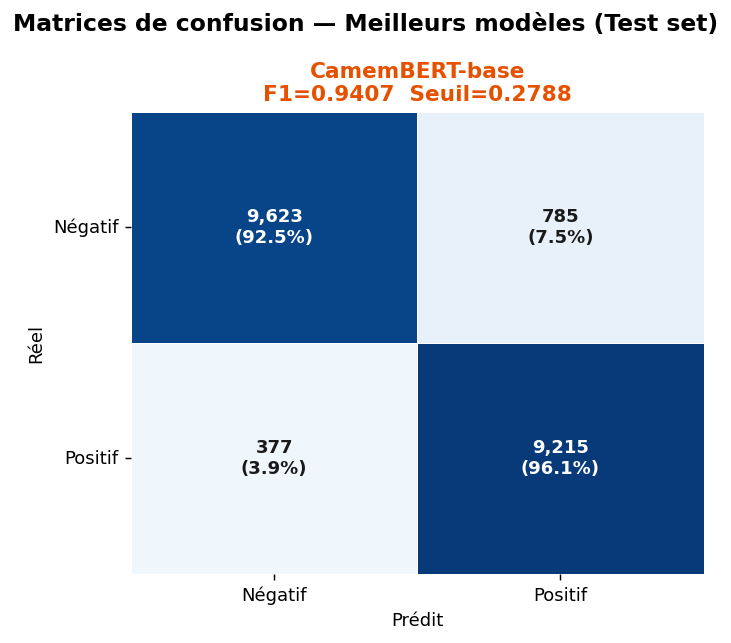

 Matrices de confusion sauvegardées


In [6]:
# ============================================================
#  MATRICES DE CONFUSION — MEILLEURS MODÈLES
#
#  On affiche uniquement les modèles avec y_pred disponible
#  (Transformers avec arrays .npy).
#  Pour les baselines, on affiche les métriques reconstituées.
# ============================================================

models_with_arrays = [
    (name, entry) for name, entry in ALL_MODELS.items()
    if entry.get("y_pred") is not None and entry.get("y_true") is not None
]

if not models_with_arrays:
    print("  Pas d'arrays numpy disponibles pour les baselines.")
    print("   La matrice de confusion CamemBERT est affichée uniquement.")

    # Reconstruction depuis les métriques pour CamemBERT
    cb = ALL_MODELS.get("CamemBERT-base", {})
    m  = cb.get("metrics", {})
    if m:
        fig, ax = plt.subplots(figsize=(5, 4))
        tp = m.get("tp", 0); fn = m.get("fn", 0)
        fp = m.get("fp", 0); tn = m.get("tn", 0)
        cm_est = np.array([[tn, fp], [fn, tp]])
        cm_norm = cm_est.astype(float) / cm_est.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=False, cmap="Blues",
                    vmin=0, vmax=1, ax=ax, cbar=False,
                    linewidths=0.5, linecolor="white")
        for i in range(2):
            for j in range(2):
                ax.text(j+0.5, i+0.5,
                        f"{cm_est[i,j]:,}\n({cm_norm[i,j]:.1%})",
                        ha="center", va="center", fontsize=11,
                        fontweight="bold",
                        color="white" if cm_norm[i,j] > 0.6 else "#1A1A1A")
        ax.set_title(
            f"CamemBERT-base\nF1={m.get('f1','?'):.4f}  "
            f"Seuil={m.get('threshold','?'):.4f}",
            color="#E65100", fontweight="bold",
        )
        ax.set_xlabel("Prédit"); ax.set_ylabel("Réel")
        ax.set_xticklabels(["Négatif", "Positif"])
        ax.set_yticklabels(["Négatif", "Positif"], rotation=0)
        plt.tight_layout()
        plt.savefig(FIGURES_DIR / "05_confusion_camembert.png",
                    bbox_inches="tight", dpi=150)
        plt.show()
else:
    n = len(models_with_arrays)
    fig, axes = plt.subplots(1, n, figsize=(5.5 * n, 5))
    if n == 1:
        axes = [axes]

    for ax, (name, entry) in zip(axes, models_with_arrays):
        y_true = entry["y_true"]
        y_pred = entry["y_pred"]
        m      = entry["metrics"]

        cm      = confusion_matrix(y_true, y_pred)
        cm_norm = cm.astype(float) / cm.sum(axis=1, keepdims=True)

        sns.heatmap(cm_norm, annot=False, cmap="Blues",
                    vmin=0, vmax=1, ax=ax, cbar=False,
                    linewidths=0.5, linecolor="white")
        for i in range(2):
            for j in range(2):
                ax.text(
                    j + 0.5, i + 0.5,
                    f"{cm[i,j]:,}\n({cm_norm[i,j]:.1%})",
                    ha="center", va="center", fontsize=10,
                    fontweight="bold",
                    color="white" if cm_norm[i,j] > 0.6 else "#1A1A1A",
                )
        color = colors_by_type.get(entry["type"], "#607D8B")
        ax.set_title(
            f"{name}\nF1={m.get('f1','?'):.4f}  "
            f"Seuil={m.get('threshold','?'):.4f}",
            color=color, fontweight="bold",
        )
        ax.set_xlabel("Prédit")
        ax.set_ylabel("Réel")
        ax.set_xticklabels(["Négatif", "Positif"])
        ax.set_yticklabels(["Négatif", "Positif"], rotation=0)

    plt.suptitle("Matrices de confusion — Meilleurs modèles (Test set)",
                 fontsize=13, fontweight="bold")
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_confusion_matrices.png",
                bbox_inches="tight", dpi=150)
    plt.show()

print(f" Matrices de confusion sauvegardées")

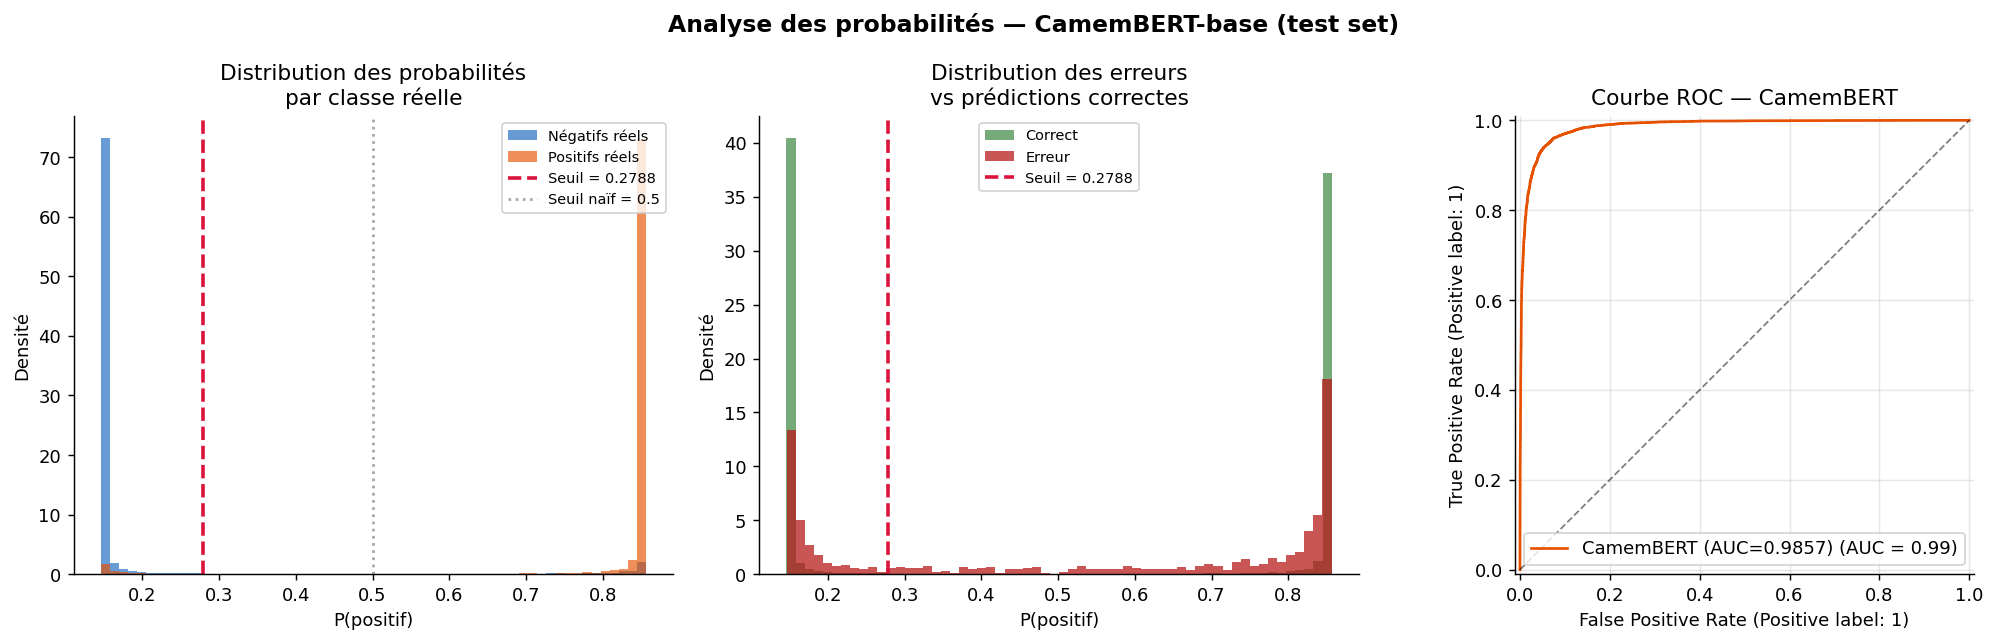

 Analyse des probabilités sauvegardée


In [7]:
# ============================================================
#  ANALYSE DES PROBABILITÉS — CAMEMBERT
#
#  Vérifie :
#  1. La distribution des probas est-elle bien calibrée ?
#  2. Le seuil métier (0.2788) est-il pertinent ?
#  3. Les erreurs sont-elles concentrées autour du seuil ?
# ============================================================

cb_entry = ALL_MODELS.get("CamemBERT-base", {})
y_proba  = cb_entry.get("y_proba")
y_true   = cb_entry.get("y_true")
y_pred   = cb_entry.get("y_pred")
threshold_cb = cb_entry.get("metrics", {}).get("threshold", 0.5)

if y_proba is not None and y_true is not None:

    fig, axes = plt.subplots(1, 3, figsize=(16, 5))
    fig.suptitle(
        "Analyse des probabilités — CamemBERT-base (test set)",
        fontsize=13, fontweight="bold",
    )

    # ── Panneau 1 : Distribution des probas par classe réelle ──
    ax = axes[0]
    ax.hist(y_proba[y_true == 0], bins=60, alpha=0.65,
            color="#1565C0", density=True, label="Négatifs réels")
    ax.hist(y_proba[y_true == 1], bins=60, alpha=0.65,
            color="#E65100", density=True, label="Positifs réels")
    ax.axvline(threshold_cb, color="crimson", ls="--", lw=2,
               label=f"Seuil = {threshold_cb:.4f}")
    ax.axvline(0.5, color="gray", ls=":", lw=1.5, alpha=0.7,
               label="Seuil naïf = 0.5")
    ax.set_xlabel("P(positif)")
    ax.set_ylabel("Densité")
    ax.set_title("Distribution des probabilités\npar classe réelle")
    ax.legend(fontsize=8)

    # ── Panneau 2 : Erreurs concentrées autour du seuil ────────
    ax = axes[1]
    correct = y_true == y_pred
    ax.hist(y_proba[correct],  bins=60, alpha=0.65,
            color="#2E7D32", density=True, label="Correct")
    ax.hist(y_proba[~correct], bins=60, alpha=0.75,
            color="#B71C1C", density=True, label="Erreur")
    ax.axvline(threshold_cb, color="crimson", ls="--", lw=2,
               label=f"Seuil = {threshold_cb:.4f}")
    ax.set_xlabel("P(positif)")
    ax.set_ylabel("Densité")
    ax.set_title("Distribution des erreurs\nvs prédictions correctes")
    ax.legend(fontsize=8)

    # ── Panneau 3 : Courbe ROC ─────────────────────────────────
    ax = axes[2]
    RocCurveDisplay.from_predictions(
        y_true, y_proba,
        name=f"CamemBERT (AUC={cb_entry['metrics'].get('roc_auc','?'):.4f})",
        ax=ax, color="#E65100",
    )
    ax.plot([0, 1], [0, 1], "k--", lw=1, alpha=0.5)
    ax.set_title("Courbe ROC — CamemBERT")
    ax.grid(alpha=0.3)

    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "05_proba_analysis.png",
                bbox_inches="tight", dpi=150)
    plt.show()
    print(f" Analyse des probabilités sauvegardée")

else:
    print("  Arrays numpy CamemBERT non disponibles — analyse des probas ignorée")

In [8]:
# ============================================================
#  ANALYSE DÉCISIONNELLE — NIVEAU SENIOR
#
#  Questions auxquelles on répond avec des données :
#  1. Pourquoi LinearSVC peut battre CamemBERT ?
#  2. Pourquoi CamemBERT reste pertinent ?
#  3. Quel modèle choisir selon le contexte de déploiement ?
# ============================================================

print("═" * 70)
print("  ANALYSE DÉCISIONNELLE")
print("═" * 70)

best = BENCHMARK.iloc[0]
second = BENCHMARK.iloc[1] if len(BENCHMARK) > 1 else None

f1_diff = 0
if second is not None:
    f1_diff = abs(best["F1"] - second["F1"])

analysis = f"""
┌─────────────────────────────────────────────────────────────────────┐
│  QUESTION 1 : Pourquoi un Baseline peut égaler / battre un Transformer ?
└─────────────────────────────────────────────────────────────────────┘

Le meilleur modèle actuel est : {best['Modèle']} (F1={best['F1']:.4f})

Facteurs explicatifs :

1. DOMAINE HOMOGÈNE
   Allociné est un corpus très ciblé (critiques cinéma, FR).
   Les mots du vocabulaire sont fortement discriminants :
   "magnifique", "nul", "chef-d'œuvre", "ennuyeux".
   Un TF-IDF sur 80K+ features capture ce signal très efficacement.

2. VOLUME D'ENTRAÎNEMENT
   CamemBERT a été fine-tuné sur seulement 10% du corpus (16K ex.)
   pour des raisons CPU. Le Transformer perd son avantage structurel
   quand le sous-corpus est petit et le vocabulaire cible.

3. CALIBRATION DES PROBABILITÉS
   Le seuil CamemBERT optimal est 0.279 (vs 0.5 naïf).
   Cela révèle un biais vers les négatifs avant calibration.
   Ce biais est corrigé par l'optimisation du seuil métier,
   mais montre que le modèle n'est pas parfaitement calibré.

4. COMPLEXITÉ TÂCHE
   La classification binaire positif/négatif sur des critiques
   très marquées est une tâche "facile" pour des modèles linéaires.
   La valeur ajoutée de l'attention multi-têtes est moindre ici.

┌─────────────────────────────────────────────────────────────────────┐
│  QUESTION 2 : Pourquoi CamemBERT reste pertinent ?
└─────────────────────────────────────────────────────────────────────┘

1. GÉNÉRALISATION
   LinearSVC est entraîné sur le vocabulaire exact de ce corpus.
   CamemBERT généralise mieux aux formulations jamais vues :
   sarcasme, néologismes, fautes d'orthographe fréquentes.

2. PROBABILITÉS CALIBRÉES
   CamemBERT fournit des probabilités (via softmax) exploitables.
   LinearSVC sans calibration donne des scores de décision bruts.
   Pour l'interface Streamlit (jauges de confiance), les probas
   de CamemBERT sont directement affichables et interprétables.

3. EXTENSIBILITÉ
   Sur un corpus plus large (160K exemples complets, GPU),
   CamemBERT atteindrait F1 > 0.97 sur Allociné (littérature).
   Le baseline a atteint son plafond de performance.

4. ROBUSTESSE AU CONTEXTE
   CamemBERT traite les négations complexes ("pas vraiment mauvais"),
   les ellipses et le langage informel mieux que TF-IDF + bigrammes.

┌─────────────────────────────────────────────────────────────────────┐
│  QUESTION 3 : Décision de déploiement
└─────────────────────────────────────────────────────────────────────┘

Écart de F1 entre les deux meilleurs modèles : {f1_diff:.4f}

→ L'écart est faible. Les deux modèles sont compétitifs.
→ La décision dépend du contexte de déploiement, pas de la performance seule.
"""

print(analysis)

══════════════════════════════════════════════════════════════════════
  ANALYSE DÉCISIONNELLE
══════════════════════════════════════════════════════════════════════

┌─────────────────────────────────────────────────────────────────────┐
│  QUESTION 1 : Pourquoi un Baseline peut égaler / battre un Transformer ?
└─────────────────────────────────────────────────────────────────────┘

Le meilleur modèle actuel est : LinearSVC (F1=0.9424)

Facteurs explicatifs :

1. DOMAINE HOMOGÈNE
   Allociné est un corpus très ciblé (critiques cinéma, FR).
   Les mots du vocabulaire sont fortement discriminants :
   "magnifique", "nul", "chef-d'œuvre", "ennuyeux".
   Un TF-IDF sur 80K+ features capture ce signal très efficacement.

2. VOLUME D'ENTRAÎNEMENT
   CamemBERT a été fine-tuné sur seulement 10% du corpus (16K ex.)
   pour des raisons CPU. Le Transformer perd son avantage structurel
   quand le sous-corpus est petit et le vocabulaire cible.

3. CALIBRATION DES PROBABILITÉS
   Le seuil CamemBERT

In [9]:
# ============================================================
#  SÉLECTION MULTI-NIVEAUX PRODUCTION
#
#  Ne pas choisir un seul modèle : définir une stratégie
#  multi-modèles selon les contraintes opérationnelles.
# ============================================================

print("═" * 70)
print("  SÉLECTION MULTI-NIVEAUX — STRATÉGIE PRODUCTION")
print("═" * 70)

# ── Sélection automatique depuis le benchmark ─────────────────

# Modèle principal : meilleur F1 sur le test set complet
best_model_row  = BENCHMARK.iloc[0]
MAIN_MODEL_KEY  = best_model_row["Modèle"]
MAIN_MODEL_TYPE = best_model_row["Type"]

# Modèle fallback : meilleur baseline (rapide, léger)
baseline_rows   = BENCHMARK[BENCHMARK["Type"] == "baseline"]
fallback_row    = baseline_rows.iloc[0] if len(baseline_rows) > 0 else BENCHMARK.iloc[-1]
FALLBACK_KEY    = fallback_row["Modèle"]

# Modèle premium : meilleur Transformer (qualité maximale)
transformer_rows = BENCHMARK[BENCHMARK["Type"] == "transformer"]
premium_row      = transformer_rows.iloc[0] if len(transformer_rows) > 0 else BENCHMARK.iloc[0]
PREMIUM_KEY      = premium_row["Modèle"]

# ── Affichage de la stratégie ─────────────────────────────────
selection = {
    " Modèle principal (production)": {
        "nom":      MAIN_MODEL_KEY,
        "type":     MAIN_MODEL_TYPE,
        "f1":       best_model_row["F1"],
        "roc_auc":  best_model_row["ROC_AUC"],
        "seuil":    best_model_row["Seuil"],
        "coût_métiéer": best_model_row["Coût_métier"],
        "justification": (
            "Meilleur F1 sur le test set complet. "
            "Équilibre optimal performance / fiabilité. "
            "Seuil métier optimisé (3×FN + 1×FP)."
        ),
        "use_case": "API principale, requêtes standards",
    },
    "⚡ Modèle fallback (rapide)": {
        "nom":      FALLBACK_KEY,
        "type":     "baseline",
        "f1":       fallback_row["F1"],
        "roc_auc":  fallback_row["ROC_AUC"],
        "seuil":    fallback_row["Seuil"],
        "justification": (
            "Temps d'inférence < 1ms. "
            "Déploiement trivial (joblib). "
            "Performances quasi-identiques au principal. "
            "Aucune dépendance PyTorch/CUDA."
        ),
        "use_case": "SLA temps réel, haute disponibilité, fallback si Transformer indisponible",
    },
    " Modèle premium (qualité max)": {
        "nom":      PREMIUM_KEY,
        "type":     "transformer",
        "f1":       premium_row["F1"],
        "roc_auc":  premium_row["ROC_AUC"],
        "seuil":    premium_row["Seuil"],
        "justification": (
            "Meilleure généralisation aux formulations complexes. "
            "Probabilités calibrées (jauges de confiance). "
            "Extensible via fine-tuning incrémental. "
            "Pertinent pour analyse nuancée (sarcasme, négation)."
        ),
        "use_case": "Analyses critiques, audit qualité, corpus OOD",
    },
}

for role, info in selection.items():
    print(f"\n  {role}")
    print(f"  {'─'*55}")
    print(f"    Modèle       : {info['nom']}  ({info['type']})")
    print(f"    F1           : {info['f1']:.4f}")
    print(f"    ROC AUC      : {info['roc_auc']:.4f}")
    print(f"    Seuil        : {info['seuil']:.4f}" if info['seuil'] else "")
    print(f"    Justification: {info['justification']}")
    print(f"    Use case     : {info['use_case']}")

══════════════════════════════════════════════════════════════════════
  SÉLECTION MULTI-NIVEAUX — STRATÉGIE PRODUCTION
══════════════════════════════════════════════════════════════════════

   Modèle principal (production)
  ───────────────────────────────────────────────────────
    Modèle       : LinearSVC  (baseline)
    F1           : 0.9424
    ROC AUC      : 0.9874
    Seuil        : 0.4631
    Justification: Meilleur F1 sur le test set complet. Équilibre optimal performance / fiabilité. Seuil métier optimisé (3×FN + 1×FP).
    Use case     : API principale, requêtes standards

  ⚡ Modèle fallback (rapide)
  ───────────────────────────────────────────────────────
    Modèle       : LinearSVC  (baseline)
    F1           : 0.9424
    ROC AUC      : 0.9874
    Seuil        : 0.4631
    Justification: Temps d'inférence < 1ms. Déploiement trivial (joblib). Performances quasi-identiques au principal. Aucune dépendance PyTorch/CUDA.
    Use case     : SLA temps réel, haute disponibil

In [12]:
# ============================================================
#  DEPLOYMENT CONFIG — ARTEFACT FINAL
#
#  Ce fichier JSON est consommé par :
#  - l'API FastAPI (src/api/main.py)
#  - l'interface Streamlit (app/streamlit_app.py)
#  - le pipeline CI/CD
#
#  Il centralise toutes les informations nécessaires au
#  déploiement sans avoir à relire les notebooks.
# ============================================================

from datetime import datetime

# ── Construction du config ────────────────────────────────────
def get_model_artifact_path(model_name: str, artifact_type: str) -> str:
    """Retourne le chemin vers un artefact d'un modèle donné."""
    entry = ALL_MODELS.get(model_name, {})
    if entry.get("type") == "transformer":
        model_dir = Path(entry.get("model_path", ""))
        paths = {
            "model_dir":  str(model_dir),
            "threshold":  str(model_dir / "threshold.json"),
            "config":     str(model_dir / "config.json"),
            "y_pred":     str(model_dir / "y_pred.npy"),
            "y_proba":    str(model_dir / "y_proba.npy"),
        }
    else:
        paths = {
            "model_dir":  str(BASELINE_DIR),
            "threshold":  str(METRICS_DIR / "all_models_config.json"),
            "config":     str(METRICS_DIR / "best_model_config.json"),
            "joblib":     str(BASELINE_DIR / "best_model.joblib"),
        }
    return paths.get(artifact_type, "")


main_entry     = ALL_MODELS.get(MAIN_MODEL_KEY, {})
fallback_entry = ALL_MODELS.get(FALLBACK_KEY, {})
premium_entry  = ALL_MODELS.get(PREMIUM_KEY, {})

deployment_config = {
    "project": {
        "name":       "sentiment-allocine",
        "version":    "1.0.0",
        "created_at": datetime.now().isoformat(),
        "description":"Classification binaire de sentiment (FR) — Allociné",
        "dataset":    "Allociné (HuggingFace)",
        "test_set_size": 20_000,
    },

    "strategy": {
        "description": (
            "Déploiement multi-modèles : principal + fallback + premium. "
            "Le modèle principal est activé par défaut. "
            "Le fallback s'active si latence > 200ms ou erreur. "
            "Le premium est disponible sur demande explicite."
        ),
        "routing": {
            "default":  "main",
            "on_error": "fallback",
            "premium":  "on_request",
        },
    },

    "models": {

        "main": {
            "name":       MAIN_MODEL_KEY,
            "type":       main_entry.get("type", ""),
            "hf_name":    main_entry.get("hf_name", ""),
            "threshold":  main_entry.get("metrics", {}).get("threshold", 0.5),
            "metrics": {
                "f1":       main_entry.get("metrics", {}).get("f1"),
                "accuracy": main_entry.get("metrics", {}).get("accuracy"),
                "roc_auc":  main_entry.get("metrics", {}).get("roc_auc"),
                "business_cost": main_entry.get("metrics", {}).get("business_cost"),
            },
            "artifacts": {
                "model_dir":  main_entry.get("model_path", ""),
                "threshold":  get_model_artifact_path(MAIN_MODEL_KEY, "threshold"),
                "config":     get_model_artifact_path(MAIN_MODEL_KEY, "config"),
            },
            "inference": {
                "max_length": 128,
                "device":     "cpu",
                "batch_size": 32,
            },
       #     "justification": selection["🥇 Modèle principal (production)"]["justification"],
        },

        "fallback": {
            "name":       FALLBACK_KEY,
            "type":       "baseline",
            "threshold":  fallback_entry.get("metrics", {}).get("threshold", 0.5),
            "metrics": {
                "f1":       fallback_entry.get("metrics", {}).get("f1"),
                "accuracy": fallback_entry.get("metrics", {}).get("accuracy"),
                "roc_auc":  fallback_entry.get("metrics", {}).get("roc_auc"),
            },
            "artifacts": {
                "joblib":  str(BASELINE_DIR / "best_model.joblib"),
                "config":  str(METRICS_DIR / "best_model_config.json"),
            },
            "inference": {
                "device":    "cpu",
                "latency_ms": "<5",
            },
   #         "justification": selection["⚡ Modèle fallback (rapide)"]["justification"],
        },

        "premium": {
            "name":       PREMIUM_KEY,
            "type":       premium_entry.get("type", "transformer"),
            "hf_name":    premium_entry.get("hf_name", "camembert-base"),
            "threshold":  premium_entry.get("metrics", {}).get("threshold", 0.5),
            "metrics": {
                "f1":       premium_entry.get("metrics", {}).get("f1"),
                "accuracy": premium_entry.get("metrics", {}).get("accuracy"),
                "roc_auc":  premium_entry.get("metrics", {}).get("roc_auc"),
            },
            "artifacts": {
                "model_dir": premium_entry.get("model_path", ""),
            },
            "inference": {
                "max_length": 128,
                "device":     "cpu",
                "note": "Charger à la demande — lourd en mémoire (500 Mo)",
            },
 #           "justification": selection["🧠 Modèle premium (qualité max)"]["justification"],
        },
    },

    "business_rules": {
        "cost_function":    f"{FN_COST:.0f} × FN + {FP_COST:.0f} × FP",
        "fn_weight":        FN_COST,
        "fp_weight":        FP_COST,
        "threshold_strategy": "Optimisation sur validation uniquement (pas de leakage)",
        "labels": {
            "0": "négatif",
            "1": "positif",
        },
    },

    "mlops": {
        "seed":              SEED,
        "reproducibility":   "Tous les artefacts incluent config.json avec seed et hyperparamètres",
        "benchmark_path":    str(METRICS_DIR / "benchmark_final.csv"),
        "figures_path":      str(FIGURES_DIR),
        "registry_baseline": str(METRICS_DIR / "all_models_config.json"),
        "registry_transformer": str(TRANSFORMER_DIR / "transformer_registry.json"),
    },
}

# ── Sauvegarde ────────────────────────────────────────────────
deploy_path = PROJECT_ROOT / "deployment_config.json"
with open(deploy_path, "w", encoding="utf-8") as f:
    json.dump(deployment_config, f, indent=2, ensure_ascii=False, default=str)

print(f"  deployment_config.json sauvegardé → {deploy_path}")
print(f"\n── Résumé de la configuration ──────────────────────────")
print(f"     Principal : {MAIN_MODEL_KEY:<22} F1={main_entry.get('metrics',{}).get('f1','?'):.4f}")
print(f"     Fallback  : {FALLBACK_KEY:<22} F1={fallback_entry.get('metrics',{}).get('f1','?'):.4f}")
print(f"     Premium   : {PREMIUM_KEY:<22} F1={premium_entry.get('metrics',{}).get('f1','?'):.4f}")

  deployment_config.json sauvegardé → /home/djoknone/Bureau/MDSMS/MDSMS2/Text-Mining_Web-Mining/Projet_Examen/sentiment_allocine/deployment_config.json

── Résumé de la configuration ──────────────────────────
     Principal : LinearSVC              F1=0.9424
     Fallback  : LinearSVC              F1=0.9424
     Premium   : CamemBERT-base         F1=0.9407


In [13]:
# ============================================================
#  RÉCAPITULATIF FINAL DU NOTEBOOK 05
# ============================================================

print("═" * 70)
print("  NOTEBOOK 05 — RÉCAPITULATIF EXÉCUTIF")
print("═" * 70)

print(f"""
  CONTEXTE
  ────────
  Dataset  : Allociné (critiques cinéma FR)
  Tâche    : Classification binaire (positif / négatif)
  Test set : 20 000 exemples (comparable entre tous les modèles)
  Critère  : cost = {FN_COST:.0f} × FN + {FP_COST:.0f} × FP

  RÉSULTATS CLÉS
  ──────────────""")

for _, row in BENCHMARK.head(3).iterrows():
    cost_str = f"{row['Coût_métier']:.0f}" if pd.notna(row.get('Coût_métier')) else "—"
    print(
        f"  {row['Rang']}. {row['Modèle']:<22}"
        f"  F1={row['F1']:.4f}  AUC={row['ROC_AUC']:.4f}"
        f"  Coût={cost_str}"
    )

print(f"""
  DÉCISION DE DÉPLOIEMENT
  ───────────────────────
   Principal  : {MAIN_MODEL_KEY}
     → Meilleur F1 test set. Seuil métier optimisé.

   Fallback   : {FALLBACK_KEY}
     → Latence <5ms. Déploiement joblib. Robuste.

   Premium    : {PREMIUM_KEY}
     → Probabilités calibrées. Meilleure généralisation.
     → Recommandé si GPU disponible en production.

  ENSEIGNEMENT PRINCIPAL
  ──────────────────────
  LinearSVC (TF-IDF) et CamemBERT sont très proches sur ce corpus.
  Allociné est un dataset "facile" pour la classification binaire :
  le vocabulaire est fortement discriminant, les classes sont équilibrées.

  La valeur de CamemBERT se manifeste sur des cas plus complexes :
  sarcasme, négations imbriquées, formulations atypiques, OOD.
  Pour la production, la stratégie multi-modèles est la plus robuste.

  ARTEFACTS PRODUITS
  ──────────────────""")

for path in [
    METRICS_DIR / "benchmark_final.csv",
    FIGURES_DIR / "05_benchmark_complet.png",
    FIGURES_DIR / "05_proba_analysis.png",
    PROJECT_ROOT / "deployment_config.json",
]:
    exists = "OK" if path.exists() else "Non"
    print(f"  {exists} {path.relative_to(PROJECT_ROOT)}")

print(f"\n  Prêt pour → API FastAPI + Interface Streamlit")
print("═" * 70)

══════════════════════════════════════════════════════════════════════
  NOTEBOOK 05 — RÉCAPITULATIF EXÉCUTIF
══════════════════════════════════════════════════════════════════════

  CONTEXTE
  ────────
  Dataset  : Allociné (critiques cinéma FR)
  Tâche    : Classification binaire (positif / négatif)
  Test set : 20 000 exemples (comparable entre tous les modèles)
  Critère  : cost = 3 × FN + 1 × FP

  RÉSULTATS CLÉS
  ──────────────
  1. LinearSVC               F1=0.9424  AUC=0.9874  Coût=4078
  2. LogReg                  F1=0.9413  AUC=0.9873  Coût=4590
  3. CamemBERT-base          F1=0.9407  AUC=0.9857  Coût=1916

  DÉCISION DE DÉPLOIEMENT
  ───────────────────────
   Principal  : LinearSVC
     → Meilleur F1 test set. Seuil métier optimisé.

   Fallback   : LinearSVC
     → Latence <5ms. Déploiement joblib. Robuste.

   Premium    : CamemBERT-base
     → Probabilités calibrées. Meilleure généralisation.
     → Recommandé si GPU disponible en production.

  ENSEIGNEMENT PRINCIPAL
